In [5]:
#导入python库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 6)

In [6]:
#读取数据
file_path = "../data/raw/online_shoppers_intention.csv"

df = pd.read_csv(file_path)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
#重新确认数据粒度
df.shape

(12330, 18)

In [8]:
df.columns.tolist()

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Revenue']

In [9]:
#基础EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [10]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [11]:
#均值不等于典型用户
df["ProductRelated"].median()

18.0

In [12]:
df["ProductRelated"].quantile(
    [0.25, 0.5, 0.75, 0.9, 0.95]
)

0.25      7.0
0.50     18.0
0.75     38.0
0.90     74.0
0.95    109.0
Name: ProductRelated, dtype: float64

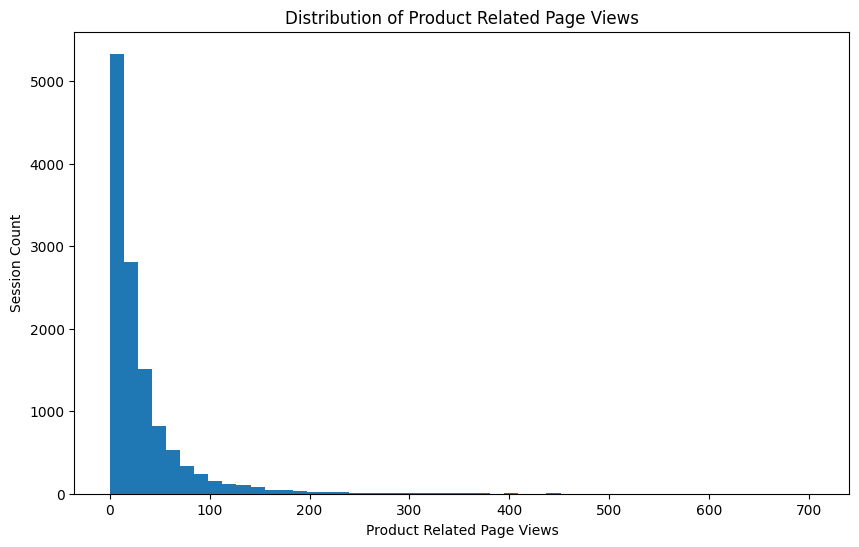

In [13]:
#ProductRelated分布
plt.figure(figsize=(10, 6))

plt.hist(
    df["ProductRelated"],
    bins=50
)

plt.xlabel("Product Related Page Views")
plt.ylabel("Session Count")
plt.title("Distribution of Product Related Page Views")

plt.show()

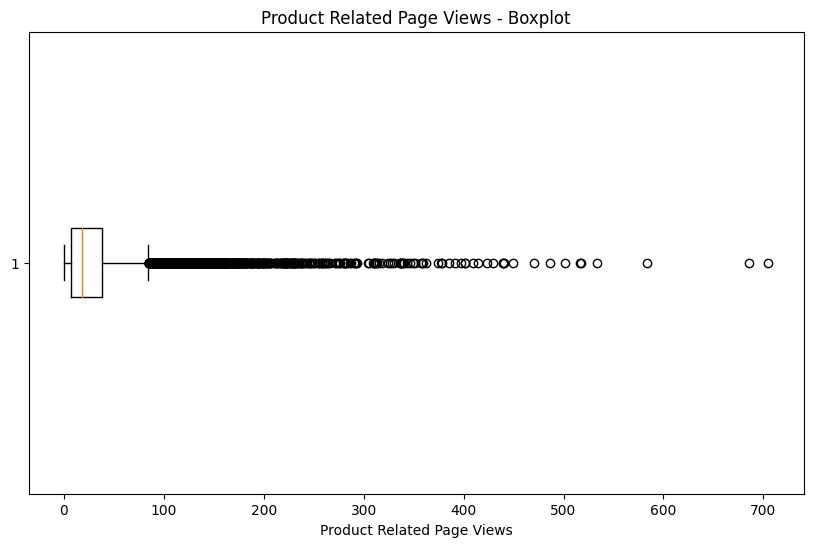

In [14]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    df["ProductRelated"],
    vert=False
)

plt.xlabel("Product Related Page Views")
plt.title("Product Related Page Views - Boxplot")

plt.show()

In [15]:
#购买 vs 未购买的商品浏览差异
df.groupby("Revenue")["ProductRelated"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Revenue,,,
False,10422,28.714642,16.0
True,1908,48.210168,29.0


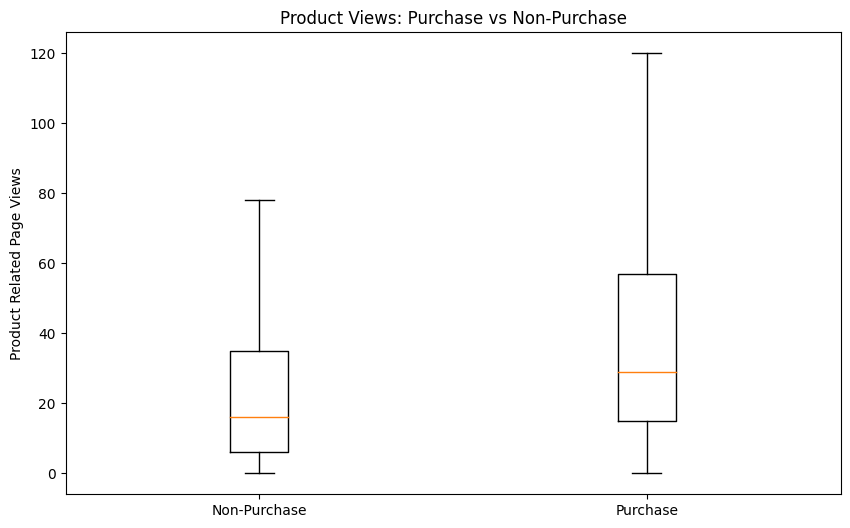

In [17]:
#箱线图
purchase_data = df.loc[
    df["Revenue"] == True,
    "ProductRelated"
]

non_purchase_data = df.loc[
    df["Revenue"] == False,
    "ProductRelated"
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    [non_purchase_data, purchase_data],
    labels=["Non-Purchase", "Purchase"],
    showfliers=False
)

plt.ylabel("Product Related Page Views")
plt.title("Product Views: Purchase vs Non-Purchase")

plt.savefig(
    "../images/product_view.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
#重新建立商品浏览分层
bins = [-1, 5, 10, 20, 50, np.inf]

labels = [
    "0-5",
    "6-10",
    "11-20",
    "21-50",
    "50+"
]

df["product_view_group"] = pd.cut(
    df["ProductRelated"],
    bins=bins,
    labels=labels
)




In [19]:
df[
    ["ProductRelated", "product_view_group"]
].head(20)

,ProductRelated,product_view_group
0,1,0-5
1,2,0-5
2,1,0-5
3,2,0-5
4,10,6-10
5,19,11-20
6,1,0-5
7,0,0-5
8,2,0-5
9,3,0-5


In [20]:
#用Pandas计算每组CVR
product_group = (
    df.groupby(
        "product_view_group",
        observed=False
    )
    .agg(
        session_cnt=("Revenue", "size"),
        purchase_cnt=("Revenue", "sum")
    )
    .reset_index()
)

In [21]:
product_group["conversion_rate"] = (
    product_group["purchase_cnt"]
    / product_group["session_cnt"]
    * 100
)

In [22]:
product_group

,product_view_group,session_cnt,purchase_cnt,conversion_rate
0,0-5,2369,102,4.305614
1,6-10,1804,185,10.254989
2,11-20,2560,392,15.312500
3,21-50,3445,685,19.883890
4,50+,2152,544,25.278810


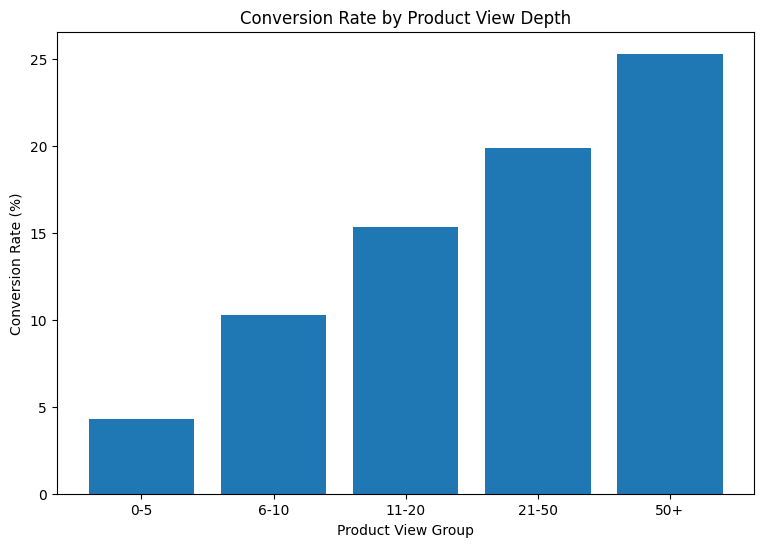

In [23]:
plt.figure(figsize=(9, 6))

plt.bar(
    product_group["product_view_group"].astype(str),
    product_group["conversion_rate"]
)

plt.xlabel("Product View Group")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Product View Depth")

plt.savefig(
    "../images/product_view_conversion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
#商品页面停留时间分析
df["product_duration_min"] = (
    df["ProductRelated_Duration"] / 60
)

In [26]:
duration_bins = [
    -1,
    2,
    5,
    10,
    20,
    np.inf
]

duration_labels = [
    "0-2min",
    "2-5min",
    "5-10min",
    "10-20min",
    "20min+"
]

df["duration_group"] = pd.cut(
    df["product_duration_min"],
    bins=duration_bins,
    labels=duration_labels
)

In [27]:
duration_group = (
    df.groupby(
        "duration_group",
        observed=False
    )
    .agg(
        session_cnt=("Revenue", "size"),
        purchase_cnt=("Revenue", "sum")
    )
    .reset_index()
)

duration_group["conversion_rate"] = (
    duration_group["purchase_cnt"]
    / duration_group["session_cnt"]
    * 100
)

duration_group

,duration_group,session_cnt,purchase_cnt,conversion_rate
0,0-2min,2361,94,3.981364
1,2-5min,1807,133,7.360266
2,5-10min,2006,308,15.353938
3,10-20min,2376,482,20.286195
4,20min+,3780,891,23.571429


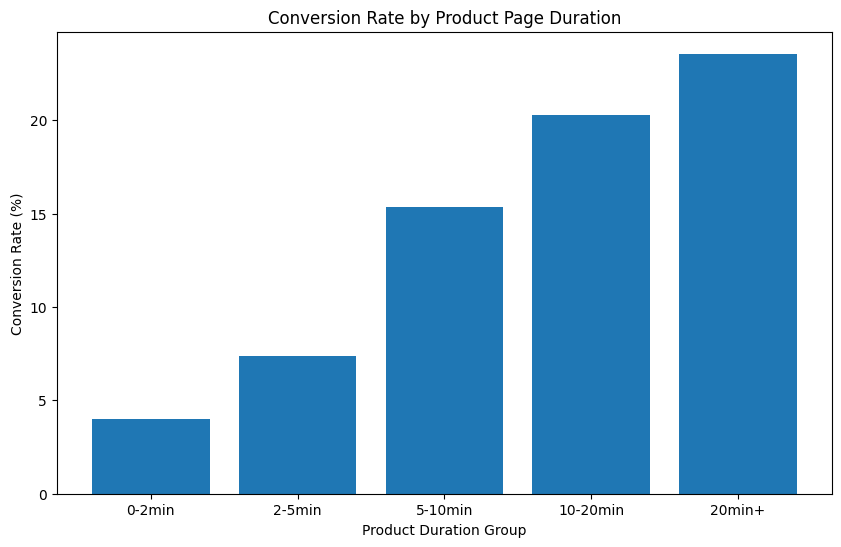

In [28]:
plt.figure(figsize=(10, 6))

plt.bar(
    duration_group["duration_group"].astype(str),
    duration_group["conversion_rate"]
)

plt.xlabel("Product Duration Group")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Product Page Duration")

plt.savefig(
    "../images/product_duration_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
#BounceRates分析
df.groupby("Revenue")["BounceRates"].agg(
    ["mean", "median"]
)

,mean,median
Revenue,,
False,0.025317,0.004255
True,0.005117,0.000000


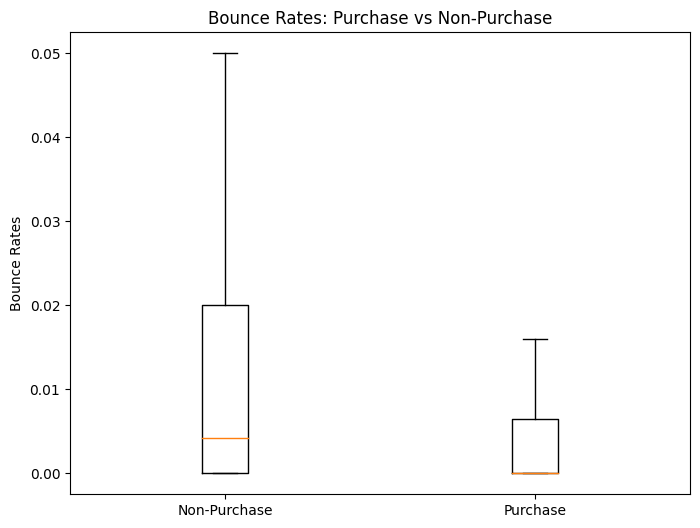

In [30]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        df.loc[df["Revenue"] == False, "BounceRates"],
        df.loc[df["Revenue"] == True, "BounceRates"]
    ],
    labels=["Non-Purchase", "Purchase"],
    showfliers=False
)

plt.ylabel("Bounce Rates")
plt.title("Bounce Rates: Purchase vs Non-Purchase")

plt.show()

In [31]:
#ExitRates分析
df.groupby("Revenue")["ExitRates"].agg(
    ["mean", "median"]
)

,mean,median
Revenue,,
False,0.047378,0.028571
True,0.019555,0.016000


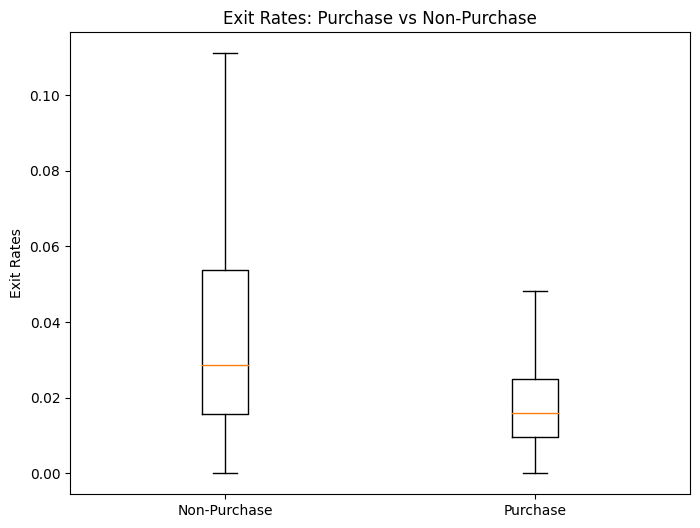

In [32]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        df.loc[df["Revenue"] == False, "ExitRates"],
        df.loc[df["Revenue"] == True, "ExitRates"]
    ],
    labels=["Non-Purchase", "Purchase"],
    showfliers=False
)

plt.ylabel("Exit Rates")
plt.title("Exit Rates: Purchase vs Non-Purchase")

plt.show()

In [33]:
#PageValues分析
df.groupby("Revenue")["PageValues"].agg(
    ["mean", "median"]
)

,mean,median
Revenue,,
False,1.975998,0.000000
True,27.264518,16.758134


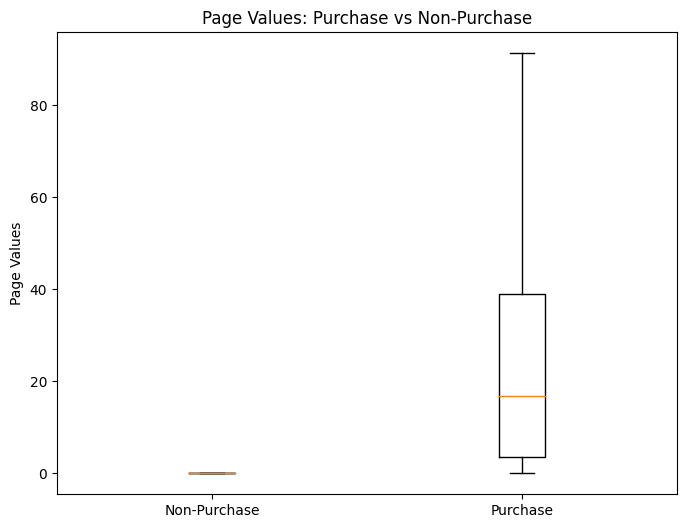

In [34]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        df.loc[df["Revenue"] == False, "PageValues"],
        df.loc[df["Revenue"] == True, "PageValues"]
    ],
    labels=["Non-Purchase", "Purchase"],
    showfliers=False
)

plt.ylabel("Page Values")
plt.title("Page Values: Purchase vs Non-Purchase")

plt.show()

In [35]:
#新老用户分析
df.groupby("VisitorType").agg(
    session_cnt=("Revenue", "size"),
    purchase_cnt=("Revenue", "sum"),
    avg_product_views=("ProductRelated", "mean"),
    avg_product_duration=("ProductRelated_Duration", "mean"),
    avg_bounce_rate=("BounceRates", "mean"),
    avg_exit_rate=("ExitRates", "mean")
)

,session_cnt,purchase_cnt,avg_product_views,avg_product_duration,avg_bounce_rate,avg_exit_rate
VisitorType,,,,,,
New_Visitor,1694,422,18.054900,636.393354,0.005261,0.020681
Other,85,16,12.470588,570.404862,0.038551,0.063349
Returning_Visitor,10551,1470,34.082457,1289.421490,0.024778,0.046505


In [36]:
visitor_analysis = (
    df.groupby("VisitorType")
    .agg(
        session_cnt=("Revenue", "size"),
        purchase_cnt=("Revenue", "sum"),
        avg_product_views=("ProductRelated", "mean"),
        avg_product_duration=("ProductRelated_Duration", "mean"),
        avg_bounce_rate=("BounceRates", "mean"),
        avg_exit_rate=("ExitRates", "mean")
    )
    .reset_index()
)

visitor_analysis["conversion_rate"] = (
    visitor_analysis["purchase_cnt"]
    / visitor_analysis["session_cnt"]
    * 100
)

visitor_analysis

,VisitorType,session_cnt,purchase_cnt,avg_product_views,avg_product_duration,avg_bounce_rate,avg_exit_rate,conversion_rate
0,New_Visitor,1694,422,18.054900,636.393354,0.005261,0.020681,24.911452
1,Other,85,16,12.470588,570.404862,0.038551,0.063349,18.823529
2,Returning_Visitor,10551,1470,34.082457,1289.421490,0.024778,0.046505,13.932329


In [37]:
#高潜Session专项分析
high_potential = df[
    (df["ProductRelated"] >= 30)
    & (df["Revenue"] == False)
].copy()

In [38]:
high_potential.shape

(3117, 21)

In [39]:
high_potential[
    [
        "ProductRelated",
        "ProductRelated_Duration",
        "BounceRates",
        "ExitRates",
        "PageValues",
        "VisitorType",
        "TrafficType",
        "Month"
    ]
].describe(include="all")

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,VisitorType,TrafficType,Month
count,3117.000000,3117.000000,3117.000000,3117.000000,3117.000000,3117,3117.000000,3117
unique,NaN,NaN,NaN,NaN,NaN,3,NaN,10
top,NaN,NaN,NaN,NaN,NaN,Returning_Visitor,NaN,Nov
freq,NaN,NaN,NaN,NaN,NaN,2930,NaN,838
mean,69.582611,2548.874010,0.008031,0.022699,4.138651,NaN,3.709978,NaN
std,54.917910,2662.900230,0.010662,0.015575,12.485963,NaN,3.683125,NaN
min,30.000000,270.491667,0.000000,0.000000,0.000000,NaN,1.000000,NaN
25%,38.000000,1143.371078,0.000081,0.012110,0.000000,NaN,2.000000,NaN
50%,52.000000,1835.556213,0.004924,0.019569,0.000000,NaN,2.000000,NaN
75%,80.000000,3060.055556,0.011000,0.029261,1.984556,NaN,4.000000,NaN


In [40]:
p75 = df["ProductRelated"].quantile(0.75)

p75

38.0

In [41]:
high_potential_p75 = df[
    (df["ProductRelated"] >= p75)
    & (df["Revenue"] == False)
].copy()

In [43]:
#高潜Session和普通未购买Session比较
non_purchase = df[
    df["Revenue"] == False
].copy()


In [44]:
comparison = pd.DataFrame({
    "high_potential": [
        high_potential_p75["BounceRates"].mean(),
        high_potential_p75["ExitRates"].mean(),
        high_potential_p75["PageValues"].mean(),
        high_potential_p75["ProductRelated_Duration"].mean()
    ],
    
    "all_non_purchase": [
        non_purchase["BounceRates"].mean(),
        non_purchase["ExitRates"].mean(),
        non_purchase["PageValues"].mean(),
        non_purchase["ProductRelated_Duration"].mean()
    ]
}, index=[
    "BounceRates",
    "ExitRates",
    "PageValues",
    "ProductRelated_Duration"
])

comparison

,high_potential,all_non_purchase
BounceRates,0.007614,0.025317
ExitRates,0.021814,0.047378
PageValues,4.182961,1.975998
ProductRelated_Duration,2941.962073,1069.987809


In [45]:
#相关性分析
corr_cols = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "Revenue"
]

In [46]:
corr_df = df[corr_cols].copy()

corr_df["Revenue"] = (
    corr_df["Revenue"].astype(int)
)

In [47]:
corr_matrix = corr_df.corr()

corr_matrix

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Revenue
ProductRelated,1.000000,0.860927,-0.204578,-0.292526,0.056282,0.158538
ProductRelated_Duration,0.860927,1.000000,-0.184541,-0.251984,0.052823,0.152373
BounceRates,-0.204578,-0.184541,1.000000,0.913004,-0.119386,-0.150673
ExitRates,-0.292526,-0.251984,0.913004,1.000000,-0.174498,-0.207071
PageValues,0.056282,0.052823,-0.119386,-0.174498,1.000000,0.492569
Revenue,0.158538,0.152373,-0.150673,-0.207071,0.492569,1.000000


In [48]:
revenue_corr = (
    corr_matrix["Revenue"]
    .sort_values(ascending=False)
)

revenue_corr

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

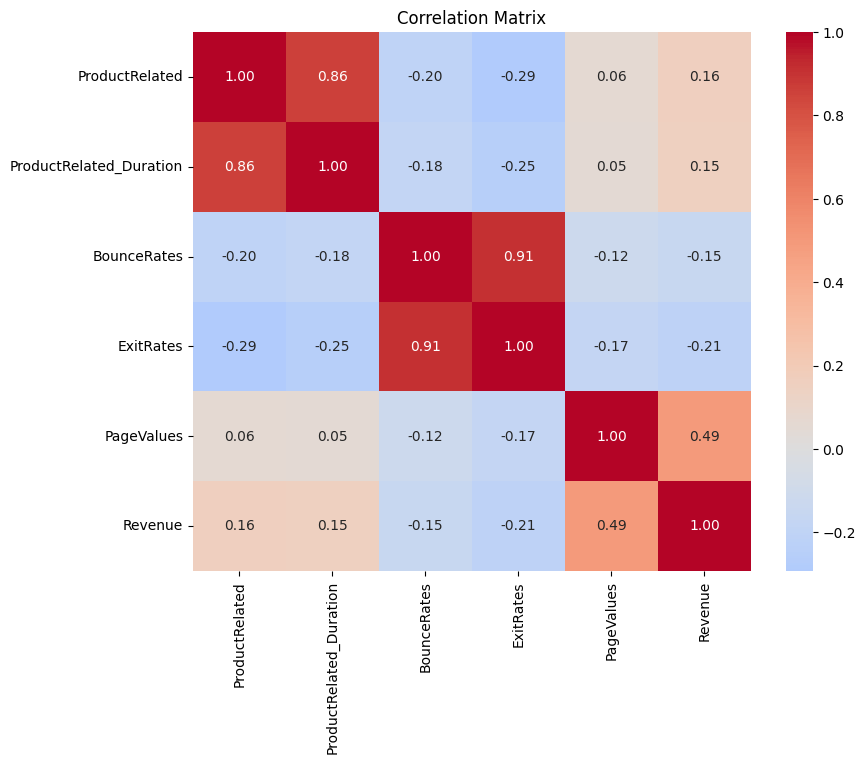

In [50]:
#画相关热力图
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()